# Content-Aware Image Resizing by Seam Carving
### A Shortest-Path Formulation on Directed Acyclic Graphs

**Abstract.** Uniform rescaling distorts the content of an image, whereas cropping discards it. *Seam carving* (Avidan & Shamir, 2007) instead removes, one at a time, connected pixel paths of low visual importance, called *seams*, so that salient structures are preserved. The number of candidate seams grows exponentially with the image height, which rules out exhaustive search. This notebook shows that the search for an optimal seam is *exactly* a single-source shortest-path problem on a weighted directed acyclic graph (DAG) whose vertices are pixels. Because the graph is acyclic, and because its row structure already provides a topological order, the optimal seam is found in $\Theta(HW)$ time, without a priority queue. We (i) formalise the problem, (ii) prove the seam–path correspondence and the correctness of the dynamic-programming recurrence as shortest-path relaxation in topological order, (iii) implement the algorithm, (iv) validate it against exhaustive enumeration and general-purpose graph algorithms (Dijkstra, Bellman–Ford), and (v) apply it to content-aware retargeting of a photograph.

**Contents**

1. Introduction
2. Setup and data
3. Problem formulation: pixel energy and seams
4. Graph-theoretic model: seams as shortest paths in a DAG
5. Implementation
6. Verification and complexity analysis
7. Application to a photograph
8. Discussion and extensions
9. Conclusion
10. References

**Requirements.** `numpy`, `matplotlib`, `scikit-image`, `networkx`, and an image file `tower.jpg` in the working directory (a bundled sample image is used as a fallback).

---

## 1. Introduction

Displaying an image on a screen of a different aspect ratio requires *retargeting*. The two classical operators are unsatisfactory: **cropping** removes content at the borders, and **uniform scaling** deforms every object, salient or not. Avidan & Shamir (2007) proposed a *content-aware* alternative. To reduce the width by one pixel, they remove a **vertical seam**, an 8-connected top-to-bottom chain of pixels with exactly one pixel per row, chosen to minimise the sum of a per-pixel *energy* (importance) function. Repeating the operation $k$ times reduces the width by $k$ pixels while sparing high-energy regions such as edges and object boundaries.

The algorithmic core is the search for the minimum-energy seam. The set of seams is exponentially large, so the question is why the search is tractable at all. The answer is **graph theory**:

* the image defines a **layered directed acyclic graph** whose vertices are pixels and whose edges connect each pixel to its three lower neighbours;
* seams are in one-to-one correspondence with **source-to-sink paths** in this graph;
* the minimum-energy seam is therefore a **shortest path**, and shortest paths in a DAG can be computed by relaxing edges in **topological order** in linear time (Cormen et al., 2022, §22.2 and §24.2).

The widely used "dynamic programming table" of seam carving is thus not an ad-hoc trick. It is the vector of shortest-path distances $\delta(s,\cdot)$ on this graph. Making this identification explicit clarifies why the algorithm is correct, what it costs, and how it can be generalised (Section 8).

**Contributions of this notebook.**

1. A formal graph model of the seam-finding problem, with proofs (Section 4).
2. An implementation that mirrors the theory: a reference edge-relaxation algorithm and a row-parallel vectorised variant, whose parallelism is justified graph-theoretically (Section 5).
3. An independent empirical validation of correctness and complexity (Section 6).
4. An application to a photograph, with seams tracked in the coordinates of the *original* image (Section 7).

## 2. Setup and data

In [1]:
import time
import itertools

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from skimage import io, color, filters, transform, data

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 10,
    "font.family": "serif",
    "mathtext.fontset": "dejavuserif",
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
})

IMAGE_PATH = "tower.jpg"
try:
    image = io.imread(IMAGE_PATH)
except OSError:
    print(f"'{IMAGE_PATH}' not found; using a sample image bundled with scikit-image instead.")
    image = data.astronaut()

image = image[..., :3]            # drop a possible alpha channel
H, W = image.shape[:2]
print(f"Image: {W} x {H} pixels (width x height), dtype={image.dtype}")

Image: 800 x 542 pixels (width x height), dtype=uint8


## 3. Problem formulation: pixel energy and seams

### 3.1 Pixel energy

Let $I$ be an RGB image with $H$ rows and $W$ columns. Pixels are indexed $(i,j)$ with row $i\in\{0,\dots,H-1\}$ and column $j\in\{0,\dots,W-1\}$. We first convert $I$ to luminance, $I_{\mathrm{gray}}$, and define the **energy** of a pixel as the magnitude of the Sobel gradient (Sobel & Feldman, 1968):

$$
e(i,j)=\sqrt{G_x(i,j)^2+G_y(i,j)^2},
$$

where $G_x$ and $G_y$ are the responses of $I_{\mathrm{gray}}$ to the horizontal and vertical Sobel kernels. Regions with strong intensity changes (edges, textures, object boundaries) have high energy; flat regions such as clear sky have low energy. The energy $e:\{0..H-1\}\times\{0..W-1\}\to\mathbb{R}_{\ge 0}$ is the *only* input the seam-finding algorithm needs. Any positive rescaling of $e$ leaves the set of minimisers unchanged, so the normalisation constant of the Sobel operator is immaterial.

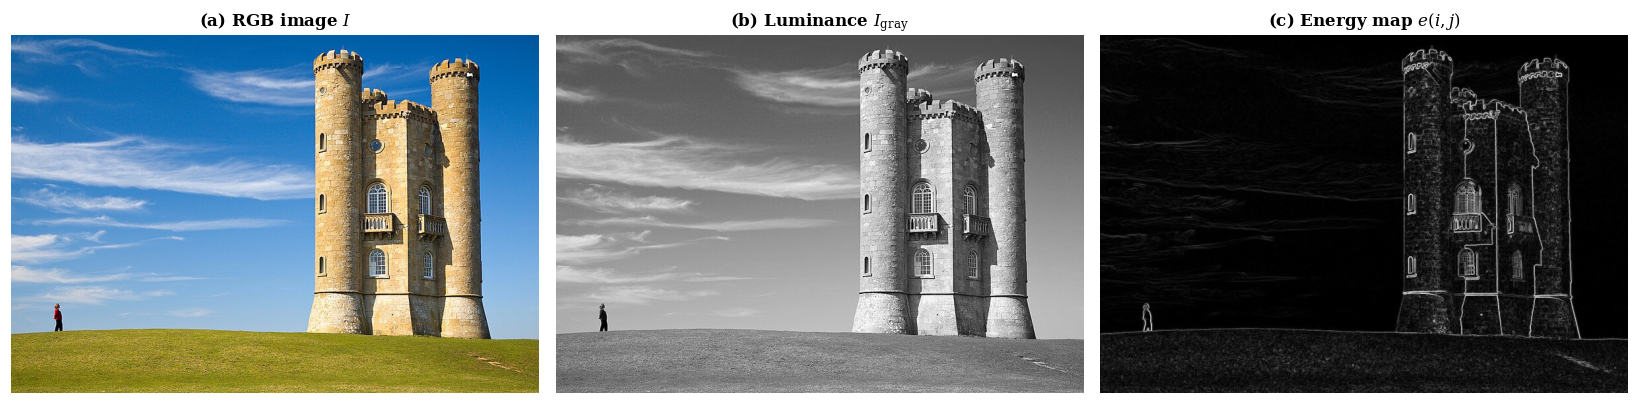

In [2]:
def compute_energy(img):
    """Gradient-magnitude energy e(i, j) of an RGB image (Sobel operator on luminance)."""
    gray = color.rgb2gray(img)          # luminance in [0, 1]
    g_y = filters.sobel_h(gray)         # derivative along the rows (responds to horizontal edges)
    g_x = filters.sobel_v(gray)         # derivative along the columns (responds to vertical edges)
    return np.hypot(g_x, g_y)           # sqrt(g_x^2 + g_y^2)


gray = color.rgb2gray(image)
energy = compute_energy(image)

# Consistency check: scikit-image's `filters.sobel` returns the same map up to the constant factor sqrt(2).
assert np.allclose(energy, np.sqrt(2) * filters.sobel(gray))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
axes[0].imshow(image);                 axes[0].set_title("(a) RGB image $I$")
axes[1].imshow(gray, cmap="gray");     axes[1].set_title(r"(b) Luminance $I_{\mathrm{gray}}$")
axes[2].imshow(energy, cmap="gray");   axes[2].set_title("(c) Energy map $e(i,j)$")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

**Figure 1.** From image to energy. Low-energy regions (dark in panel c) are cheap to remove; edges of the tower and the figure on the hill are expensive.

### 3.2 Seams and the optimisation problem

**Definition 1 (vertical seam).** A *vertical seam* is a function $\sigma:\{0,\dots,H-1\}\to\{0,\dots,W-1\}$ such that
$$
|\sigma(i)-\sigma(i-1)|\le 1\qquad\text{for all } i=1,\dots,H-1 .
$$
It selects exactly one pixel $(i,\sigma(i))$ per row, and consecutive pixels are 8-connected. Its **cost** is
$$
E(\sigma)=\sum_{i=0}^{H-1} e\big(i,\sigma(i)\big).
$$

**Problem 1 (minimum-energy seam).** Find $\sigma^\star\in\arg\min_\sigma E(\sigma)$.

The connectivity constraint is essential. Without it one would simply delete the lowest-energy pixel in each row, tearing the image apart. With it, deleting $\sigma^\star$ shifts every row left by one pixel in an *approximately coherent* way, yielding an image of width $W-1$.

**How large is the search space?** Each seam is determined by its starting column ($W$ choices) and by $H-1$ steps in $\{-1,0,+1\}$, hence the number of seams $N(H,W)$ satisfies $N(H,W)\le W\cdot 3^{H-1}$.

In [3]:
log10_bound = np.log10(W) + (H - 1) * np.log10(3)
print(f"For a {W} x {H} image: N(H, W) <= W * 3^(H-1) ~ 10^{log10_bound:.0f} candidate seams")
print("(For comparison, the observable universe contains roughly 10^80 atoms.)")

For a 800 x 542 image: N(H, W) <= W * 3^(H-1) ~ 10^261 candidate seams
(For comparison, the observable universe contains roughly 10^80 atoms.)


Brute-force enumeration is therefore out of the question, even for modest images. The next section shows that the special structure of the problem reduces it to a shortest-path computation.

## 4. Graph-theoretic model: seams as shortest paths in a DAG

### 4.1 Preliminaries

A *directed graph* is a pair $G=(V,E)$ with $E\subseteq V\times V$, equipped with a *weight function* $w:E\to\mathbb{R}$. A *path* from $u$ to $v$ is a sequence of vertices $u=v_0,v_1,\dots,v_m=v$ with $(v_{r-1},v_r)\in E$; its *weight* is $\sum_{r=1}^{m} w(v_{r-1},v_r)$. The *shortest-path distance* $\delta(u,v)$ is the minimum weight of a $u$–$v$ path ($+\infty$ if none exists). $G$ is a **directed acyclic graph (DAG)** if it contains no directed cycle. Equivalently, $G$ admits a **topological order**, a linear order of $V$ in which every edge points forward.

### 4.2 The seam graph

Given an energy map $e$ of size $H\times W$, define the weighted digraph $G_e=(V,E,w)$ by

$$
V=\{s,t\}\ \cup\ \{(i,j): 0\le i<H,\ 0\le j<W\},
$$

$$
E=\underbrace{\{(s,(0,j))\}}_{\text{source edges}}\ \cup\ 
\underbrace{\{((i,j),(i+1,j+d)) : 0\le i<H-1,\ d\in\{-1,0,1\},\ 0\le j+d<W\}}_{\text{grid edges}}\ \cup\ 
\underbrace{\{((H-1,j),t)\}}_{\text{sink edges}},
$$

with weights that charge the energy of a pixel to its **incoming** edge:

$$
w(u,v)=\begin{cases} e(v) & \text{if } v \text{ is a pixel},\\ 0 & \text{if } v=t.\end{cases}
$$

Energy is naturally a *vertex* weight. Moving it onto incoming edges converts the problem into the standard edge-weighted setting, so that the weight of an $s$–$t$ path equals the sum of the energies of all pixels it visits.

The graph has $|V|=HW+2$ vertices and $|E|=(H-1)(3W-2)+2W=\Theta(HW)$ edges: each of the $H-1$ row transitions contributes $3W-2$ edges (three per pixel, minus one at each of the two lateral borders), plus $W$ source and $W$ sink edges.

**Lemma 1 (acyclicity).** $G_e$ is a DAG, and the row-major order of pixels, preceded by $s$ and followed by $t$, is a topological order.

*Proof.* Assign each vertex a level: $\ell(s)=-1$, $\ell(i,j)=i$, $\ell(t)=H$. Every edge $(u,v)\in E$ satisfies $\ell(v)=\ell(u)+1$. Along any directed path the level strictly increases, so no vertex can be revisited and there is no directed cycle. Ordering vertices by level (ties broken arbitrarily, e.g. by column) puts every edge in forward direction. $\blacksquare$

**Lemma 2 (seams $\leftrightarrow$ $s$–$t$ paths).** The map
$$
\sigma\ \longmapsto\ \big(s,(0,\sigma(0)),(1,\sigma(1)),\dots,(H-1,\sigma(H-1)),t\big)
$$
is a bijection between vertical seams and $s$–$t$ paths in $G_e$, and the weight of the path equals $E(\sigma)$.

*Proof.* ($\Rightarrow$) For a seam $\sigma$, consecutive pixels satisfy $|\sigma(i+1)-\sigma(i)|\le 1$ and lie inside the grid, hence $((i,\sigma(i)),(i+1,\sigma(i+1)))$ is a grid edge; the first and last steps are source and sink edges. ($\Leftarrow$) Conversely, an $s$–$t$ path must start with a source edge (level $0$), and each subsequent edge raises the level by exactly one, so it visits *exactly one vertex per row* before reaching $t$ from row $H-1$. Grid edges move the column by at most one, so the visited columns define a seam. The two maps are mutually inverse. Finally, the path weight is $\sum_i e(i,\sigma(i))+0=E(\sigma)$. $\blacksquare$

**Corollary 1.** $\min_\sigma E(\sigma)=\delta(s,t)$, and the minimum-energy seam is the shortest $s$–$t$ path in $G_e$.

The connectivity constraint of Definition 1 is not something we must enforce separately: it is encoded in the *edge set*.

### 4.3 A small worked example

The following code materialises $G_e$ explicitly with NetworkX for a random $5\times 6$ integer energy map, computes the shortest path with Dijkstra's algorithm, and displays the shortest-path distances $\delta(s,(i,j))$.

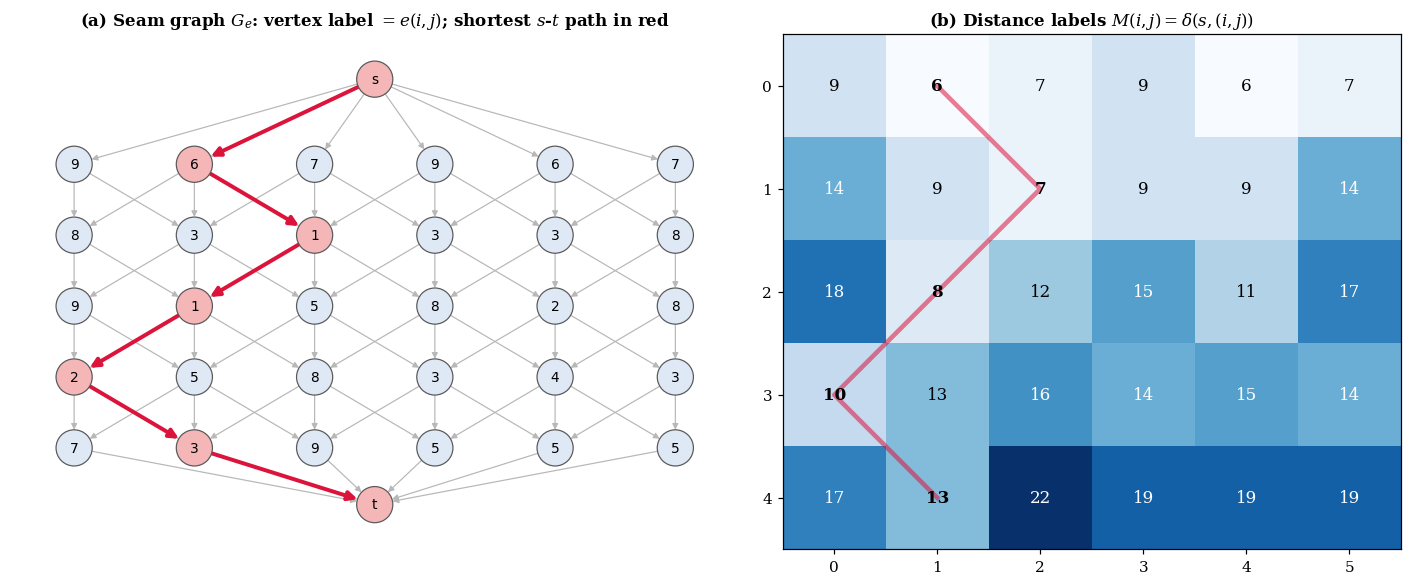

Shortest path weight delta(s,t) = 13.0 | minimum of last row of M = 13.0


In [4]:
def build_seam_dag(energy):
    """Explicitly materialise the seam graph G_e as a weighted networkx.DiGraph (Section 4.2)."""
    n_rows, n_cols = energy.shape
    G = nx.DiGraph()
    for j in range(n_cols):                                   # source edges
        G.add_edge("s", (0, j), weight=float(energy[0, j]))
    for i in range(n_rows - 1):                               # grid edges
        for j in range(n_cols):
            for d in (-1, 0, 1):
                if 0 <= j + d < n_cols:
                    G.add_edge((i, j), (i + 1, j + d), weight=float(energy[i + 1, j + d]))
    for j in range(n_cols):                                   # sink edges
        G.add_edge((n_rows - 1, j), "t", weight=0.0)
    return G


rng = np.random.default_rng(7)
e_demo = rng.integers(1, 10, size=(5, 6)).astype(float)
h, w = e_demo.shape
G_demo = build_seam_dag(e_demo)

path = nx.dijkstra_path(G_demo, "s", "t", weight="weight")
delta = nx.single_source_dijkstra_path_length(G_demo, "s", weight="weight")
M_demo = np.array([[delta[(i, j)] for j in range(w)] for i in range(h)])
seam_pixels = path[1:-1]

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(13, 5.2), gridspec_kw={"width_ratios": [1.15, 1]})

# (a) the DAG, vertex labels = energy e(i, j)
pos = {(i, j): (j, -i) for i in range(h) for j in range(w)}
pos["s"], pos["t"] = ((w - 1) / 2, 1.2), ((w - 1) / 2, -h + 0.2)
on_path = set(path)
path_edges = list(zip(path[:-1], path[1:]))
nx.draw_networkx_edges(G_demo, pos, ax=ax0, edge_color="0.72", width=0.8,
                       arrows=True, arrowsize=8, node_size=560)
nx.draw_networkx_edges(G_demo, pos, ax=ax0, edgelist=path_edges, edge_color="crimson", width=2.6,
                       arrows=True, arrowsize=12, node_size=560)
nx.draw_networkx_nodes(G_demo, pos, ax=ax0, node_size=560,
                       node_color=["#f4b6b6" if v in on_path else "#dfe8f5" for v in G_demo.nodes],
                       edgecolors="0.35", linewidths=0.8)
labels = {v: (str(int(e_demo[v])) if v not in ("s", "t") else v) for v in G_demo.nodes}
nx.draw_networkx_labels(G_demo, pos, labels=labels, ax=ax0, font_size=9)
ax0.set_title("(a) Seam graph $G_e$: vertex label $=e(i,j)$; shortest $s$-$t$ path in red")
ax0.axis("off")

# (b) shortest-path distances delta(s, (i, j)) = DP table
ax1.imshow(M_demo, cmap="Blues")
ax1.plot([p[1] for p in seam_pixels], [p[0] for p in seam_pixels], "-", color="crimson", lw=3, alpha=0.55, zorder=1)
for i in range(h):
    for j in range(w):
        ax1.text(j, i, int(M_demo[i, j]), ha="center", va="center", fontsize=11, zorder=3,
                 color="white" if M_demo[i, j] > 0.6 * M_demo.max() else "black",
                 fontweight="bold" if (i, j) in seam_pixels else "normal")
ax1.set_title(r"(b) Distance labels $M(i,j)=\delta(s,(i,j))$")
ax1.set_xticks(range(w)); ax1.set_yticks(range(h))
plt.tight_layout()
plt.show()

print("Shortest path weight delta(s,t) =", delta["t"], "| minimum of last row of M =", M_demo[-1].min())

**Figure 2.** (a) The seam graph of a toy energy map. (b) The table of distances from the source; the last row's minimum equals $\delta(s,t)$.

### 4.4 Optimal substructure and the recurrence

**Theorem 1 (dynamic-programming recurrence).** Let $M(i,j)=\delta\big(s,(i,j)\big)$. Then
$$
M(0,j)=e(0,j),\qquad 
M(i,j)=e(i,j)+\min_{\substack{d\in\{-1,0,1\}\\0\le j+d<W}} M(i-1,\,j+d)\quad (i\ge 1),
$$
and $\delta(s,t)=\min_{j} M(H-1,j)$.

*Proof.* Every path to $(0,j)$ is the single source edge, of weight $e(0,j)$. Let $i\ge1$. Any $s$–$(i,j)$ path ends with an edge $((i-1,j'),(i,j))$ for some admissible $j'=j+d$, and its prefix is an $s$–$(i-1,j')$ path. Hence its weight is at least $M(i-1,j')+e(i,j)$. Conversely, appending the edge $((i-1,j'),(i,j))$ to a *shortest* $s$–$(i-1,j')$ path attains exactly $M(i-1,j')+e(i,j)$. Minimising over the admissible $j'$ gives the recurrence. The last claim follows from the sink edges having weight $0$. $\blacksquare$

This is the *optimal-substructure property* of shortest paths (Cormen et al., 2022, Lemma 24.1) and Bellman's principle of optimality (Bellman, 1957): a subpath of a shortest path is itself a shortest path.

### 4.5 Algorithm: relaxation in topological order

Theorem 1 is one instance of the general algorithm for shortest paths in a DAG.

> **Algorithm 1: DAG-SHORTEST-PATHS$(G,w,s)$**
> 1. for every vertex $v$: $d[v]\gets\infty$, $\pi[v]\gets\text{nil}$; then $d[s]\gets 0$
> 2. **for** each vertex $u$ *in topological order*:
> 3. $\quad$ **for** each edge $(u,v)\in E$:
> 4. $\qquad$ **if** $d[u]+w(u,v)<d[v]$: $\ d[v]\gets d[u]+w(u,v)$, $\ \pi[v]\gets u$ $\qquad$ *(relaxation)*

When $u$ is processed, all its in-neighbours have already been processed, so $d[u]=\delta(s,u)$ is final. Each edge is relaxed exactly once. On $G_e$ the row-major order of Lemma 1 *is* a topological order, so no separate topological sort is needed. The predecessor pointers $\pi$ form a **shortest-path tree** rooted at $s$; the optimal seam is the tree path ending at $t$, recovered by *backtracking* from $t$.

**Theorem 2 (complexity).** Algorithm 1 runs in $\Theta(|V|+|E|)=\Theta(HW)$ time and uses $\Theta(HW)$ memory on $G_e$.

The following table compares Algorithm 1 to general-purpose single-source shortest-path algorithms on $G_e$.

| Algorithm | Requirement on weights | Time on $G_e$ |
|---|---|---|
| **DAG relaxation (Algorithm 1)** | none (negative weights allowed) | $\Theta(\lvert V\rvert+\lvert E\rvert)=\Theta(HW)$ |
| Dijkstra (binary heap) | non-negative | $O(\lvert E\rvert\log\lvert V\rvert)=O(HW\log HW)$ |
| Bellman–Ford | none, no negative cycles | $O(\lvert V\rvert\lvert E\rvert)=O(H^2W^2)$ |

Recognising the DAG structure therefore removes both the priority queue of Dijkstra's algorithm and the $|V|$ passes of Bellman–Ford. Acyclicity also makes negative weights harmless, which Dijkstra's algorithm cannot handle; we return to this in Section 8.

## 5. Implementation

The graph $G_e$ is **never materialised** in the production code: its edges are implicit (a pixel's out-neighbours are its three lower neighbours), so an $H\times W$ array of distances $d$ and an $H\times W$ array of predecessor pointers $\pi$ suffice. Two variants of Algorithm 1 are provided:

* `relax_edges` is a literal transcription of Algorithm 1 (pixel by pixel, edge by edge). It serves as the reference.
* `relax_layers` processes an entire *row* at a time with array operations. This is justified by the graph structure: all vertices of a level are pairwise unreachable from one another (levels strictly increase along paths), so they form an **antichain** in the reachability order. Their relaxations are mutually independent and can be executed simultaneously. Only the $H$ levels themselves form a dependency chain, which fixes the sequential depth of the algorithm at $\Theta(H)$.

In [5]:
class SeamDAG:
    """
    Implicit seam graph G_e of an energy map (Section 4.2) with the data of Algorithm 1.

    Attributes
    ----------
    dist   : (H, W) array, dist[i, j]   = delta(s, (i, j)) after relaxation   (the DP table M)
    parent : (H, W) array, parent[i, j] = column of the predecessor of (i, j) in the shortest-path tree
    """

    def __init__(self, energy):
        self.energy = np.asarray(energy, dtype=float)
        self.H, self.W = self.energy.shape
        self._reset()

    def _reset(self):
        self.dist = np.full((self.H, self.W), np.inf)
        self.parent = np.full((self.H, self.W), -1, dtype=int)

    # ---- Algorithm 1, literal transcription --------------------------------------------------
    def relax_edges(self):
        """Relax every edge once, visiting vertices in topological (row-major) order."""
        e = self.energy
        self._reset()
        d, pi = self.dist, self.parent
        d[0, :] = e[0, :]                                   # relax the source edges (s, (0, j))
        for i in range(self.H - 1):                         # topological order = level by level
            for j in range(self.W):
                for step in (-1, 0, 1):                     # out-neighbours of (i, j)
                    k = j + step
                    if 0 <= k < self.W:
                        candidate = d[i, j] + e[i + 1, k]   # d[u] + w(u, v)
                        if candidate < d[i + 1, k]:         # relax(u, v)
                            d[i + 1, k] = candidate
                            pi[i + 1, k] = j
        return self

    # ---- Row-parallel variant (relaxations within a level are independent) -------------------
    def relax_layers(self):
        """Relax all edges entering one level simultaneously."""
        e = self.energy
        self._reset()
        d, pi = self.dist, self.parent
        cols = np.arange(self.W)
        d[0, :] = e[0, :]
        for i in range(1, self.H):
            prev = np.concatenate(([np.inf], d[i - 1], [np.inf]))
            # candidate distances through the left, upper and right predecessor of every pixel of row i
            candidates = np.stack((prev[:-2], prev[1:-1], prev[2:]))
            choice = candidates.argmin(axis=0)                       # 0: left, 1: up, 2: right
            d[i] = e[i] + candidates[choice, cols]
            pi[i] = cols + choice - 1
        return self

    # ---- Path recovery ------------------------------------------------------------------------
    def min_seam(self):
        """
        Backtrack the shortest-path tree from the sink t.

        Returns
        -------
        seam : (H,) int array, seam[i] = column of the seam in row i
        cost : float, delta(s, t) = E(seam)
        """
        seam = np.empty(self.H, dtype=int)
        seam[-1] = np.argmin(self.dist[-1])                 # the cheapest sink edge (., t)
        for i in range(self.H - 1, 0, -1):
            seam[i - 1] = self.parent[i, seam[i]]
        return seam, float(self.dist[-1, seam[-1]])

    def seam_cost(self, seam):
        """E(sigma) for an arbitrary seam, computed directly from Definition 1."""
        return float(self.energy[np.arange(self.H), seam].sum())


def is_valid_seam(seam, n_cols):
    """Definition 1: one pixel per row, inside the image, consecutive columns differ by at most 1."""
    seam = np.asarray(seam)
    return bool(seam.min() >= 0 and seam.max() < n_cols and np.all(np.abs(np.diff(seam)) <= 1))

### 5.1 Seam removal and iterated carving

Removing a seam deletes one pixel per row. We implement it with a Boolean mask. After each removal the energy must be **recomputed**, because deleting a seam makes previously non-adjacent pixels neighbours and thereby changes the local gradients. Hence the graph $G_e$ itself changes at every iteration.

A seam found in the $t$-th iteration is expressed in the coordinates of the *current* (already narrowed) image. To display or analyse all seams in the coordinates of the *original* image, we maintain an index map `origin` in which `origin[i, j]` is the original column of the pixel that currently sits at $(i,j)$, and we apply the same removals to it.

In [6]:
def remove_seam(arr, seam):
    """Delete the seam from an (H, W) or (H, W, C) array; the width shrinks by one."""
    n_rows, n_cols = arr.shape[:2]
    keep = np.ones((n_rows, n_cols), dtype=bool)
    keep[np.arange(n_rows), seam] = False
    return arr[keep].reshape((n_rows, n_cols - 1) + arr.shape[2:])


def carve_seams(img, k, verbose=True):
    """
    Iteratively remove k minimum-energy vertical seams (greedy strategy).

    Returns
    -------
    carved : image of width W - k
    seams  : (k, H) int array; seams[t, i] = column, in the ORIGINAL image, of the t-th removed seam in row i
    costs  : (k,) float array; costs[t] = delta(s, t) = energy of the t-th seam in the image it was removed from
    """
    n_rows, n_cols = img.shape[:2]
    assert 0 <= k < n_cols, "cannot remove more seams than columns"
    rows = np.arange(n_rows)
    current = img.copy()
    origin = np.tile(np.arange(n_cols), (n_rows, 1))   # origin[i, j]: original column of the pixel now at (i, j)
    seams, costs = [], []
    for t in range(k):
        if verbose and t % 50 == 0:
            print(f"  removing seam {t + 1}/{k}")
        graph = SeamDAG(compute_energy(current)).relax_layers()
        seam, cost = graph.min_seam()
        seams.append(origin[rows, seam])
        costs.append(cost)
        current = remove_seam(current, seam)
        origin = remove_seam(origin, seam)
    return current, np.array(seams), np.array(costs)

**Complexity of the whole procedure.** Each iteration recomputes the energy ($\Theta(HW)$), runs Algorithm 1 ($\Theta(HW)$) and deletes a seam ($\Theta(HW)$ for the array copy). Removing $k$ seams thus costs $\Theta(k\,HW)$.

## 6. Verification and complexity analysis

The correctness of the implementation is checked at three independent levels.

1. **Ground truth by exhaustive enumeration** on tiny instances, using only Definition 1 (no graph theory involved).
2. **Cross-validation against general-purpose graph algorithms** (Dijkstra, Bellman–Ford, and a topological-order relaxation on the explicitly built graph) on a medium-size instance, including the *entire* distance table, not just the final value.
3. **Structural properties** of the graph (Lemma 1, vertex and edge counts).

### 6.1 Exhaustive enumeration

In [7]:
def brute_force_min_cost(energy):
    """Minimum of E(sigma) over ALL seams, by explicit enumeration of Definition 1."""
    n_rows, n_cols = energy.shape
    best = np.inf
    rows = np.arange(n_rows)
    for start in range(n_cols):
        for steps in itertools.product((-1, 0, 1), repeat=n_rows - 1):
            cols = start + np.concatenate(([0], np.cumsum(steps)))
            if cols.min() < 0 or cols.max() >= n_cols:
                continue
            best = min(best, energy[rows, cols].sum())
    return best


rng = np.random.default_rng(42)
n_trials, agree = 100, 0
for trial in range(n_trials):
    # alternate between continuous energies and small integers (many ties)
    e = rng.random((6, 5)) if trial % 2 == 0 else rng.integers(0, 3, size=(6, 5)).astype(float)
    truth = brute_force_min_cost(e)
    ok = True
    for variant in ("relax_edges", "relax_layers"):
        g = getattr(SeamDAG(e), variant)()
        seam, cost = g.min_seam()
        ok &= is_valid_seam(seam, e.shape[1]) and np.isclose(cost, truth) and np.isclose(g.seam_cost(seam), truth)
    agree += ok
print(f"DAG relaxation agrees with exhaustive enumeration on {agree}/{n_trials} random instances (6 x 5 grids).")
assert agree == n_trials

DAG relaxation agrees with exhaustive enumeration on 100/100 random instances (6 x 5 grids).


### 6.2 Cross-validation on the explicit graph

We now build $G_e$ for a $40\times 60$ random energy map and compare $\delta(s,t)$, and the full distance table $M$, computed by
(i) the vectorised algorithm, (ii) the literal Algorithm 1, (iii) NetworkX's Dijkstra, (iv) NetworkX's Bellman–Ford, and (v) a *generic* topological-order relaxation that knows nothing about the grid.

In [8]:
def dag_sssp(G, source, weight="weight"):
    """Algorithm 1 on an arbitrary weighted DAG (topological order from networkx)."""
    dist = {v: np.inf for v in G}
    dist[source] = 0.0
    for u in nx.topological_sort(G):
        for v, attr in G[u].items():
            if dist[u] + attr[weight] < dist[v]:
                dist[v] = dist[u] + attr[weight]
    return dist


rng = np.random.default_rng(1)
e = rng.random((40, 60))
G = build_seam_dag(e)

# --- structural properties (Lemma 1 and the size formulas of Section 4.2) ---
n_rows, n_cols = e.shape
assert nx.is_directed_acyclic_graph(G)
level = lambda v: -1 if v == "s" else (n_rows if v == "t" else v[0])
assert all(level(v) == level(u) + 1 for u, v in G.edges)     # every edge raises the level by exactly one
assert G.number_of_nodes() == n_rows * n_cols + 2
assert G.number_of_edges() == (n_rows - 1) * (3 * n_cols - 2) + 2 * n_cols
print(f"|V| = {G.number_of_nodes()}, |E| = {G.number_of_edges()}  (matches HW+2 and (H-1)(3W-2)+2W); graph is a DAG.")

# --- distances from several independent algorithms ---
d_dijkstra = nx.single_source_dijkstra_path_length(G, "s")
d_bellman = nx.single_source_bellman_ford_path_length(G, "s")
d_generic = dag_sssp(G, "s")
M_layers = SeamDAG(e).relax_layers().dist
M_edges = SeamDAG(e).relax_edges().dist
M_ref = np.array([[d_dijkstra[(i, j)] for j in range(n_cols)] for i in range(n_rows)])

for name, M in [("relax_layers", M_layers), ("relax_edges", M_edges)]:
    assert np.allclose(M, M_ref), name
for name, d in [("Bellman-Ford", d_bellman), ("generic DAG relaxation", d_generic)]:
    assert np.isclose(d["t"], d_dijkstra["t"]), name
    assert all(np.isclose(d[(i, j)], M_ref[i, j]) for i in range(n_rows) for j in range(n_cols)), name

print(f"delta(s,t): Dijkstra={d_dijkstra['t']:.6f}  Bellman-Ford={d_bellman['t']:.6f}  "
      f"generic DAG={d_generic['t']:.6f}  vectorised DP={M_layers[-1].min():.6f}")
print("All distance tables (HW vertices) coincide.")

# the two variants of Algorithm 1 also produce the same shortest-path tree (same tie-breaking: leftmost predecessor)
assert np.array_equal(SeamDAG(e).relax_layers().parent, SeamDAG(e).relax_edges().parent)

|V| = 2402, |E| = 7062  (matches HW+2 and (H-1)(3W-2)+2W); graph is a DAG.
delta(s,t): Dijkstra=6.633906  Bellman-Ford=6.633906  generic DAG=6.633906  vectorised DP=6.633906
All distance tables (HW vertices) coincide.


### 6.3 Empirical running time

Theorem 2 predicts $\Theta(HW)$ time for Algorithm 1 versus $O(HW\log HW)$ for Dijkstra's algorithm. We time the three implementations on random $n\times n$ energy maps. (Timings depend on the machine. The graph construction for Dijkstra is excluded from its timing. Both `relax_edges` and Dijkstra are interpreted Python, whereas `relax_layers` is vectorised, so the vertical gap between the curves reflects implementation as much as asymptotics. The informative feature is the *growth rate*.)

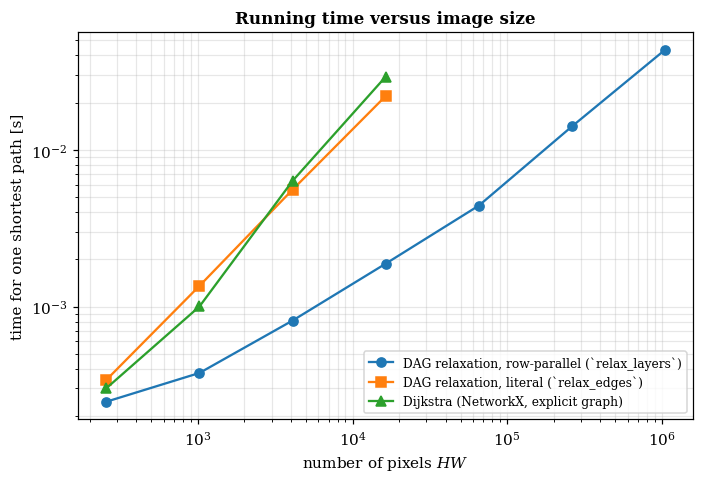

Empirical exponent of `relax_layers` for n >= 256 (log-log slope of time vs HW): 0.83
n = 128: literal relaxation 0.022s | Dijkstra 0.029s | vectorised 0.0019s


In [9]:
def best_time(fn, repeat=3):
    times = []
    for _ in range(repeat):
        t0 = time.perf_counter()
        fn()
        times.append(time.perf_counter() - t0)
    return min(times)


rng = np.random.default_rng(0)
sizes_fast = [16, 32, 64, 128, 256, 512, 1024]
sizes_slow = [16, 32, 64, 128]
t_layers, t_edges, t_dijkstra = {}, {}, {}

for n in sizes_fast:
    e = rng.random((n, n))
    t_layers[n] = best_time(lambda: SeamDAG(e).relax_layers().min_seam())
for n in sizes_slow:
    e = rng.random((n, n))
    G = build_seam_dag(e)
    t_edges[n] = best_time(lambda: SeamDAG(e).relax_edges().min_seam())
    t_dijkstra[n] = best_time(lambda: nx.dijkstra_path_length(G, "s", "t"))

fig, ax = plt.subplots(figsize=(6.5, 4.5))
for label, table, style in [("DAG relaxation, row-parallel (`relax_layers`)", t_layers, "o-"),
                            ("DAG relaxation, literal (`relax_edges`)", t_edges, "s-"),
                            ("Dijkstra (NetworkX, explicit graph)", t_dijkstra, "^-")]:
    ns = sorted(table)
    ax.loglog([n * n for n in ns], [table[n] for n in ns], style, label=label)
ax.set_xlabel("number of pixels $HW$")
ax.set_ylabel("time for one shortest path [s]")
ax.set_title("Running time versus image size")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

big = [n for n in sizes_fast if n >= 256]
slope = np.polyfit(np.log([n * n for n in big]), np.log([t_layers[n] for n in big]), 1)[0]
print(f"Empirical exponent of `relax_layers` for n >= 256 (log-log slope of time vs HW): {slope:.2f}")
for n in sizes_slow[-1:]:
    print(f"n = {n}: literal relaxation {t_edges[n]:.3f}s | Dijkstra {t_dijkstra[n]:.3f}s | vectorised {t_layers[n]:.4f}s")

**Figure 3.** Running time of one shortest-path computation as a function of the number of pixels (log–log). A slope of $1$ corresponds to linear time in $HW$. All curves grow roughly linearly. For the vectorised variant the fitted exponent is somewhat below $1$ at these sizes, because the fixed interpreter overhead of its $H$ row iterations is still significant next to the array work; the operation count itself is $\Theta(HW)$. The logarithmic factor in Dijkstra's bound is too small to be resolved in this range, so the comparison shows that the DAG algorithm is at least as fast as Dijkstra while being simpler and not requiring non-negative weights.

## 7. Application to a photograph

### 7.1 One seam: distance labels and the optimal path

We first inspect a single seam on the original image. Panel (b) displays the distance labels $M(i,j)=\delta(s,(i,j))$, the table produced by Algorithm 1 for this image, and panel (a) shows the optimal seam obtained by backtracking from the sink.

Minimum seam energy delta(s,t) = 5.234  (mean per pixel: 0.0097; mean energy of the whole image: 0.0620)


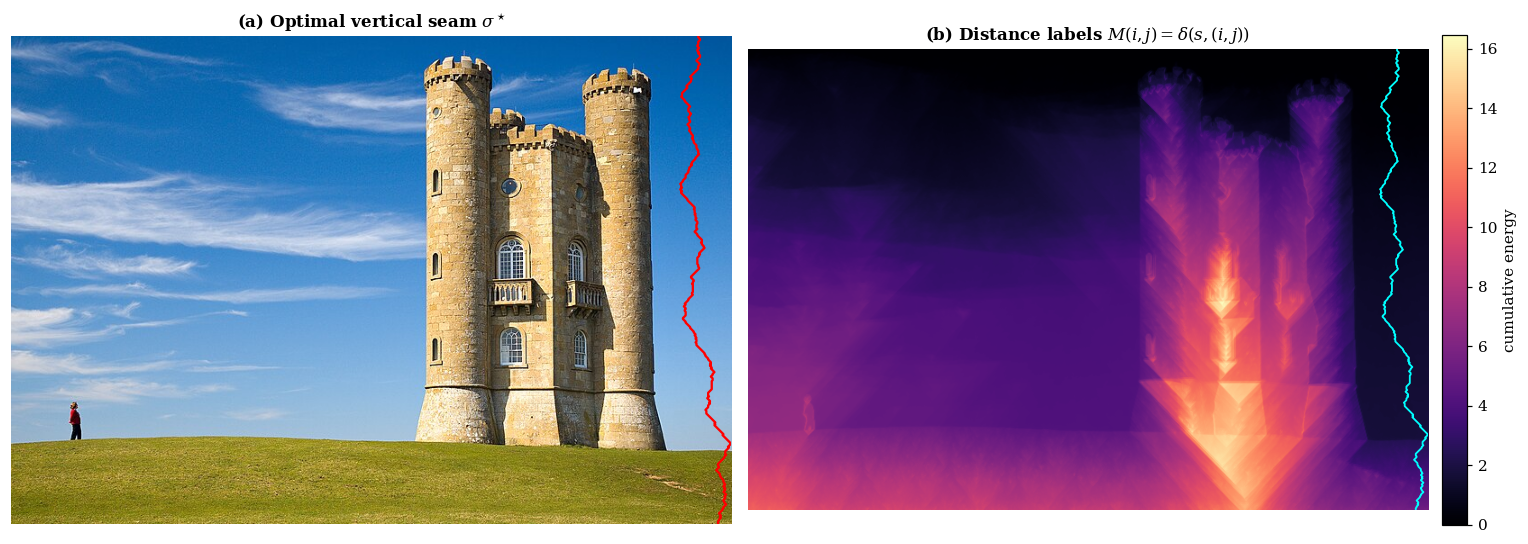

In [10]:
graph = SeamDAG(energy).relax_layers()
seam, cost = graph.min_seam()
assert is_valid_seam(seam, W) and np.isclose(cost, graph.seam_cost(seam))
print(f"Minimum seam energy delta(s,t) = {cost:.3f}  (mean per pixel: {cost / H:.4f}; "
      f"mean energy of the whole image: {energy.mean():.4f})")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
axes[0].imshow(image)
axes[0].plot(seam, np.arange(H), color="red", lw=1.5)
axes[0].set_title("(a) Optimal vertical seam $\\sigma^\\star$")
im = axes[1].imshow(graph.dist, cmap="magma")
axes[1].plot(seam, np.arange(H), color="cyan", lw=1.2)
axes[1].set_title(r"(b) Distance labels $M(i,j)=\delta(s,(i,j))$")
fig.colorbar(im, ax=axes[1], fraction=0.035, pad=0.02, label="cumulative energy")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

**Figure 4.** Left: the minimum-energy seam. Right: the shortest-path distance labels; $M$ increases from top to bottom because each row adds non-negative weights. The seam is the backtracked path of the shortest-path tree from the sink; it runs through low-energy sky and grass and avoids the high-energy tower.

### 7.2 Removing $k$ seams

In [11]:
K = min(300, W // 2)
print(f"Removing {K} vertical seams:")
t0 = time.perf_counter()
carved, seams, costs = carve_seams(image, K)
print(f"Done in {time.perf_counter() - t0:.1f} s. Output size: {carved.shape[1]} x {carved.shape[0]}")

Removing 300 vertical seams:
  removing seam 1/300
  removing seam 51/300
  removing seam 101/300
  removing seam 151/300
  removing seam 201/300
  removing seam 251/300
Done in 11.0 s. Output size: 500 x 542


**Sanity checks on the bookkeeping.** The $K$ seams, expressed in *original* coordinates, must be pairwise disjoint (each pixel is removed at most once), and deleting exactly those pixels from the original image must reproduce the carved image.

In [12]:
rows_rep = np.repeat(np.arange(H), K)          # row index of every removed pixel
cols_flat = seams.T.ravel()                    # matching original column index

keep = np.ones((H, W), dtype=bool)
keep[rows_rep, cols_flat] = False

assert keep.sum() == H * (W - K), "seams overlap in original coordinates"
assert np.array_equal(image[keep].reshape(H, W - K, 3), carved), "index map inconsistent with carved image"
print("Seams are pairwise disjoint and reproduce the carved image exactly.")

Seams are pairwise disjoint and reproduce the carved image exactly.


### 7.3 Comparison with cropping and uniform scaling

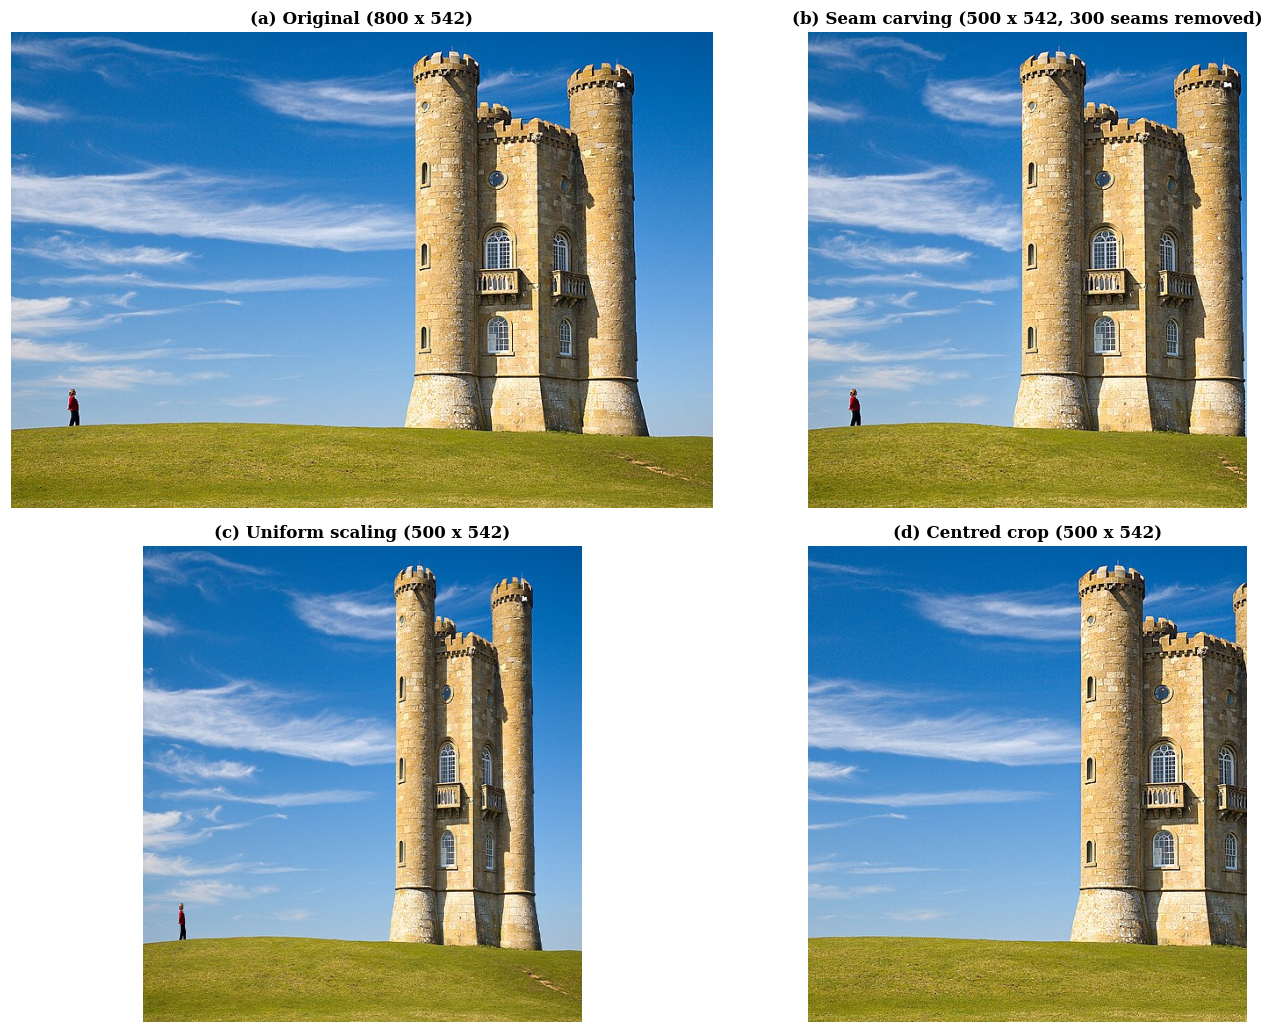

In [13]:
scaled = transform.resize(image, (H, W - K), anti_aliasing=True)          # uniform horizontal scaling
left = K // 2
cropped = image[:, left:left + (W - K)]                                    # centred crop

fig, axes = plt.subplots(2, 2, figsize=(13, 9.5))
panels = [(image, f"(a) Original ({W} x {H})"),
          (carved, f"(b) Seam carving ({W - K} x {H}, {K} seams removed)"),
          (scaled, f"(c) Uniform scaling ({W - K} x {H})"),
          (cropped, f"(d) Centred crop ({W - K} x {H})")]
for ax, (img, title) in zip(axes.ravel(), panels):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

**Figure 5.** Width reduction by three operators. Seam carving preserves the proportions of the tower and the person, whereas uniform scaling squeezes them; cropping removes part of the tower.

### 7.4 Where do the seams go?

Because the seams were tracked in original coordinates, they can be overlaid correctly on the original image and its energy map. (Seams found in later iterations live in an already narrowed image; plotting their *current* column indices on the original image would misplace them.) Note that in original coordinates a seam need not be 8-connected: the pixels removed earlier lie between its pixels. Only disjointness is guaranteed.

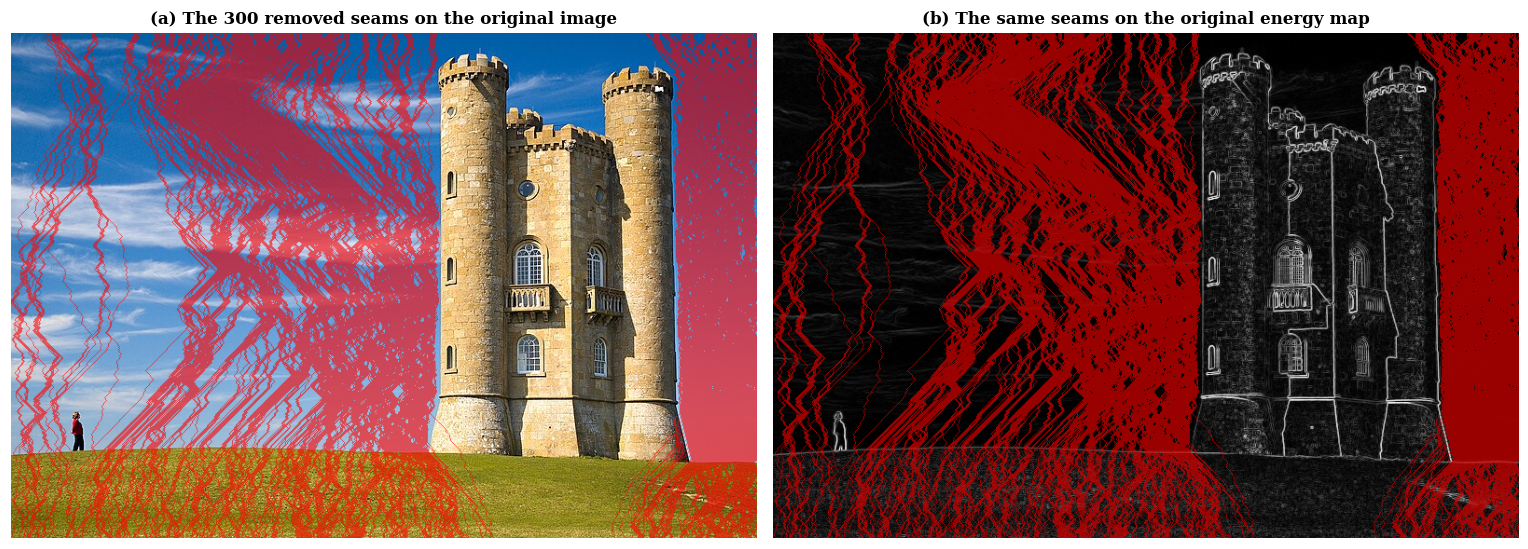

Mean original energy of the removed pixels: 0.0234  vs  image average: 0.0620 (ratio 0.38)


In [14]:
def overlay_seams(base, seams_orig, color_rgb=(1.0, 0.0, 0.0), alpha=0.6):
    """Blend the pixels of all seams (original coordinates) with a colour on a copy of `base`."""
    out = np.asarray(base, dtype=float).copy()
    if out.max() > 1.0:
        out /= 255.0
    if out.ndim == 2:
        out = np.stack([out] * 3, axis=-1)
    r, c = np.repeat(np.arange(base.shape[0]), seams_orig.shape[0]), seams_orig.T.ravel()
    out[r, c] = (1 - alpha) * out[r, c] + alpha * np.asarray(color_rgb)
    return out


energy_norm = energy / energy.max()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(overlay_seams(image, seams))
axes[0].set_title(f"(a) The {K} removed seams on the original image")
axes[1].imshow(overlay_seams(energy_norm, seams))
axes[1].set_title("(b) The same seams on the original energy map")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

removed_energy = energy[rows_rep, cols_flat].mean()
print(f"Mean original energy of the removed pixels: {removed_energy:.4f}  vs  image average: {energy.mean():.4f} "
      f"(ratio {removed_energy / energy.mean():.2f})")

**Figure 6.** The removed seams (red, semi-transparent) concentrate in the low-energy sky and grass, whereas the tower is spared; the mean original energy of the removed pixels is a fraction of the image average.

### 7.5 Cost of successive seams

Since the greedy procedure removes the cheapest seams first, the cost $\delta(s,t)$ of the $t$-th seam is expected to increase as low-energy paths are used up.

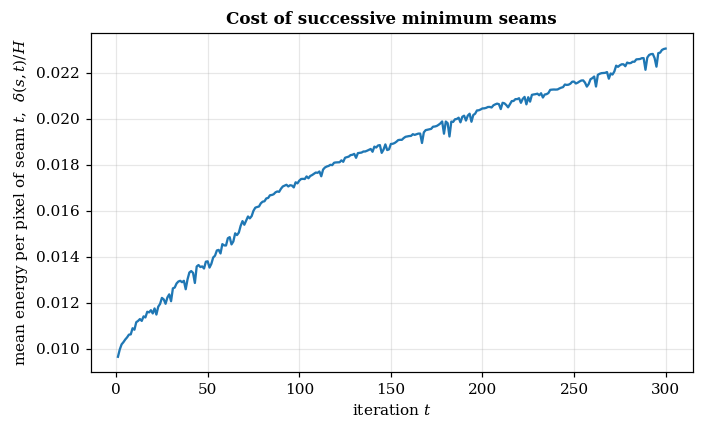

In [15]:
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(np.arange(1, K + 1), costs / H)
ax.set_xlabel("iteration $t$")
ax.set_ylabel(r"mean energy per pixel of seam $t$,  $\delta(s,t)/H$")
ax.set_title("Cost of successive minimum seams")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Figure 7.** Per-pixel cost of each successive seam.

## 8. Discussion and extensions

**The graph model as a unifying abstraction.** All variations of seam carving change only the *weights* or the *edge set* of $G_e$, never the algorithmic principle:

* **Forward energy.** The energy $e$ used here is a *backward* criterion: it measures the importance of pixels that are removed. It ignores the new edges (discontinuities) created when the two sides of a seam are joined. Rubinstein et al. (2008) proposed *forward energy*, in which the cost of traversing an edge depends on the pixels that become adjacent, i.e. on the *edge* $(u,v)$ rather than on the vertex $v$ alone. In our framework this is a different weight function $w(u,v)$ on the same DAG; Algorithm 1 is unchanged. (Rubinstein et al. also cast seam finding as a minimum $s$–$t$ cut, a formulation that extends to seam surfaces in video volumes.)
* **Protecting or removing objects.** Assigning large weights to protected regions makes seams avoid them. Assigning small or *negative* weights to a region marked for removal attracts seams to it. The DAG relaxation of Algorithm 1 remains correct for negative weights because a DAG has no cycles, and hence no negative cycles, whereas Dijkstra's algorithm would fail.
* **Horizontal seams.** Applying the algorithm to the transposed energy map yields horizontal seams. The optimal *order* in which to interleave horizontal and vertical removals for a target size can itself be computed by dynamic programming (Avidan & Shamir, 2007).

**Greedy optimality.** Each seam is a *globally* optimal solution of Problem 1 for the current image, as proved above. The *sequence* of $k$ seams, however, is chosen greedily: since each removal modifies the graph, an optimal first seam need not be part of an optimal set of $k$ seams. The $k$-step method is a heuristic for the joint problem, but one that works very well in practice and costs only $\Theta(kHW)$.

**Limitations.** The gradient-based energy has no semantic knowledge, so faces and regular structures (for example fences or facades) can be distorted when seams must cross them. This can be mitigated by combining the energy with saliency maps or user masks, as in the extensions listed above.

## 9. Conclusion

We showed that seam carving rests on a classical graph-theoretic fact. An image induces a layered DAG on its pixels; vertical seams are exactly the source-to-sink paths in this DAG; and the minimum-energy seam is a shortest path, computed in $\Theta(HW)$ time by relaxing edges in topological order. The "dynamic-programming table" is the vector of shortest-path distances from the source, and the seam is recovered from the shortest-path tree. The implementation was validated against exhaustive enumeration and against Dijkstra, Bellman–Ford and a generic DAG algorithm. Applied to a photograph, iterating the procedure reduced the width by $K$ pixels while preserving the salient structures.

## 10. References

* Avidan, S., & Shamir, A. (2007). Seam carving for content-aware image resizing. *ACM Transactions on Graphics (Proc. SIGGRAPH)*, 26(3), Article 10.
* Bellman, R. (1957). *Dynamic Programming*. Princeton University Press.
* Cormen, T. H., Leiserson, C. E., Rivest, R. L., & Stein, C. (2022). *Introduction to Algorithms* (4th ed.). MIT Press. (Topological sort and shortest paths in DAGs; optimal substructure of shortest paths.)
* Dijkstra, E. W. (1959). A note on two problems in connexion with graphs. *Numerische Mathematik*, 1, 269–271.
* Hagberg, A. A., Schult, D. A., & Swart, P. J. (2008). Exploring network structure, dynamics, and function using NetworkX. *Proceedings of the 7th Python in Science Conference (SciPy 2008)*, 11–15.
* Rubinstein, M., Shamir, A., & Avidan, S. (2008). Improved seam carving for video retargeting. *ACM Transactions on Graphics (Proc. SIGGRAPH)*, 27(3), Article 16.
* Sobel, I., & Feldman, G. (1968). A 3x3 isotropic gradient operator for image processing. Presented at the Stanford Artificial Intelligence Project (SAIL).
* van der Walt, S., et al. (2014). scikit-image: image processing in Python. *PeerJ*, 2, e453.